# **Agentic AI for deploying Green AI in business workflows**

In [1]:
!pip install datasets transformers codecarbon langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 576.3/576.3 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 73.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.5/92.5 kB 7.4 MB/s eta 0:00:00
  Attempting uninstall: termcolor
    Found existing installation: termcolor 3.0.1
    Uninstalling termcolor-3.0.1:
      

In [1]:
!pip install rouge-score pandas

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=3378a1ebc4c835f95041297c2bb1b0d2336c1ffe2d1c77e7d385b2a51f6746b5
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


In [2]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
!pip install transformers

In [9]:
!pip install langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.6 MB/s eta 0:00:00


In [10]:
from datasets import load_dataset
from transformers import pipeline
from codecarbon import EmissionsTracker
from langchain.llms import HuggingFacePipeline
import pandas as pd
import torch

In [11]:
dataset = load_dataset("argilla/FinePersonas-Conversations-Email-Summaries")
emails = dataset["train"]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.03k [00:00<?, ?B/s]

train-00000-of-00003.parquet:   0%|          | 0.00/145M [00:00<?, ?B/s]

train-00001-of-00003.parquet:   0%|          | 0.00/146M [00:00<?, ?B/s]

train-00002-of-00003.parquet:   0%|          | 0.00/146M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/363584 [00:00<?, ? examples/s]

In [18]:
MODELS = {
    "heavy": "facebook/bart-large-cnn",
    "light": "sshleifer/distilbart-cnn-6-6",
    "t5": "t5-small"
}


In [13]:
def load_model(name):
    pipe = pipeline("summarization", model=name, device=device)
    return HuggingFacePipeline(pipeline=pipe)


In [14]:
def choose_model(text, max_len=150, accuracy_critical=False):
    word_count = len(text.split())
    if accuracy_critical or word_count > max_len:
        return "heavy"
    elif word_count > 80:
        return "t5"
    else:
        return "light"


In [15]:
def track_emission(model_func, *args, **kwargs):
    tracker = EmissionsTracker()
    tracker.start()
    result = model_func(*args, **kwargs)
    emissions = tracker.stop()
    return result, emissions


In [20]:
def summarize_email(text, accuracy_critical=False):
    model_type = choose_model(text, accuracy_critical=accuracy_critical)
    model_name = MODELS[model_type]
    model = load_model(model_name)

    result, emission = track_emission(model.invoke, text)
    return result, emission, model_name


In [21]:
results = []
N = 30  # Limit for testing

for i in range(N):
    email_text = emails[i]['email']
    gold_summary = emails[i]['summary']

    summary, emission, model_used = summarize_email(email_text)

    results.append({
        "Email": email_text,
        "Reference Summary": gold_summary,
        "Generated Summary": summary,
        "Model Used": model_used,
        "Emission (kg CO2eq)": round(emission, 6)
    })

df_results = pd.DataFrame(results)
df_results.to_csv("green_ai_summaries.csv", index=False)


Device set to use cpu
[codecarbon WARNING @ 06:14:20] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 06:14:20] [setup] RAM Tracking...
[codecarbon INFO @ 06:14:20] [setup] CPU Tracking...
[codecarbon WARNING @ 06:14:21] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 06:14:21] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 06:14:21] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 06:14:21] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 06:14:21] [setup] GPU Tracking...
[codecarbon INFO @ 06:14:21] No GPU found.
[codecarbon INFO @ 06:14:21] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation

config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
[codecarbon WARNING @ 06:14:50] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 06:14:50] [setup] RAM Tracking...
[codecarbon INFO @ 06:14:50] [setup] CPU Tracking...
[codecarbon WARNING @ 06:14:51] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 06:14:51] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 06:14:51] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 06:14:51] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 06:14:51] [setup] GPU Tracking...
[codecarbon INFO @ 06:14:51] No GPU found.
[codecarbon INFO @ 06:14:51] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation

In [22]:
from IPython.display import display
display(df_results)


,Email,Reference Summary,Generated Summary,Model Used,Emission (kg CO2eq)
0,Subject: Virtual Field Trip Collaboration\n\nH...,Sarah suggests collaborating on a virtual fiel...,a virtual field trip takes students on a journ...,t5-small,0.000009
1,Subject: RE: Virtual Field Trip Collaboration\...,Michael is enthusiastic about collaborating on...,"Sarah, that's a fantastic idea! I love the ide...",t5-small,0.000009
2,Subject: RE: Virtual Field Trip Collaboration\...,Sarah is enthusiastic about the collaboration ...,I'm so glad you're on board with this idea! I ...,t5-small,0.000007
3,Subject: Need some advice on teaching climate ...,Emily is reaching out for advice on teaching t...,I'm currently working on a lesson plan for my ...,t5-small,0.000005
4,Subject: RE: Need some advice on teaching clim...,Michael is glad to provide advice on teaching ...,Using local examples and case studies can real...,facebook/bart-large-cnn,0.000062
5,Subject: RE: Need some advice on teaching clim...,Emily appreciates Michael's suggestions on tea...,"I'll definitely check out that website too, it...",t5-small,0.000006
6,Subject: Exciting new resource and conference ...,Sarah shares a dataset from the University of ...,A new dataset examines the effects of sea-leve...,facebook/bart-large-cnn,0.000054
7,Subject: RE: Exciting new resource and confere...,Michael expresses gratitude to Sarah for shari...,The interactive maps are coming along well. I'...,facebook/bart-large-cnn,0.000053
8,Subject: RE: Exciting new resource and confere...,Sarah approves the outlined key takeaways and ...,I'm happy to integrate the maps and dataset in...,t5-small,0.000006
9,"Subject: Collaborative Project on Geography, H...",Emily is reaching out to discuss a potential c...,I've been thinking about how we could create a...,facebook/bart-large-cnn,0.000050


In [30]:
results.append({
    "Email": email_text,
    "Reference Summary": gold_summary,
    "Generated Summary": summary,
    "Model Used": model_used,
    "Emission (kg CO2eq)": round(emission, 6),
    "Text Length": len(email_text.split()),
    "Summary Length": len(summary.split())
})


In [31]:
df_results = pd.DataFrame(results)


In [32]:
df_results["Text Length"] = df_results["Email"].apply(lambda x: len(x.split()))
df_results["Summary Length"] = df_results["Generated Summary"].apply(lambda x: len(x.split()))


In [24]:
!pip install matplotlib seaborn

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

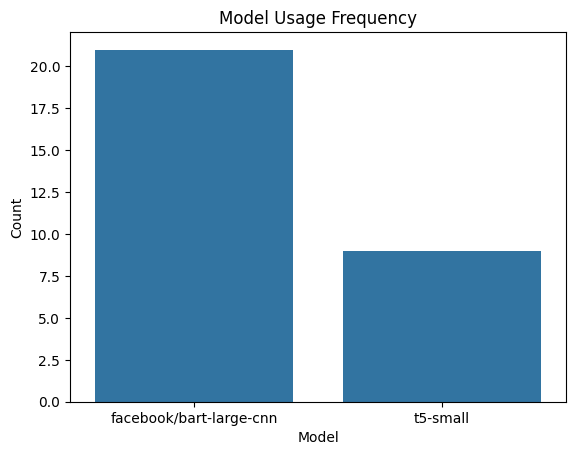

In [26]:
model_counts = df_results["Model Used"].value_counts().reset_index()
model_counts.columns = ["Model", "Count"]

sns.barplot(data=model_counts, x="Model", y="Count")
plt.title("Model Usage Frequency")
plt.show()


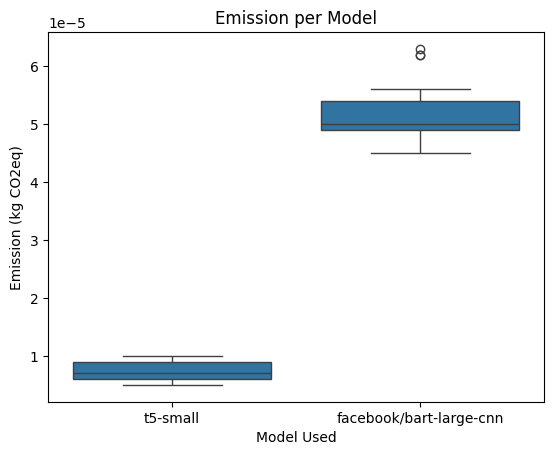

In [27]:
sns.boxplot(data=df_results, x="Model Used", y="Emission (kg CO2eq)")
plt.title("Emission per Model")
plt.show()

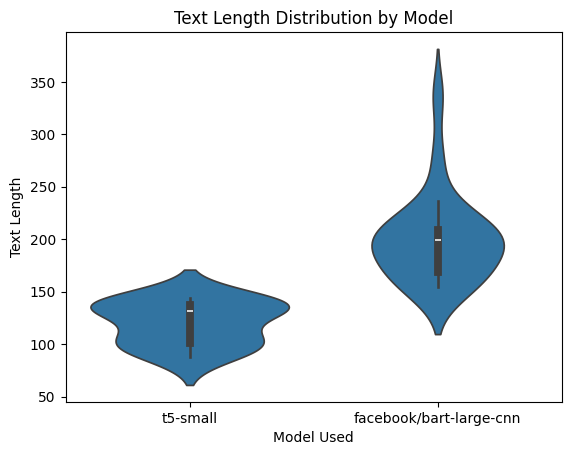

In [33]:
sns.violinplot(data=df_results, x="Model Used", y="Text Length")
plt.title("Text Length Distribution by Model")
plt.show()


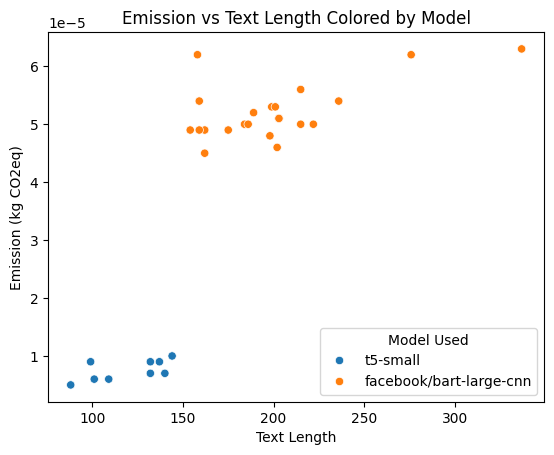

In [34]:
sns.scatterplot(data=df_results, x="Text Length", y="Emission (kg CO2eq)", hue="Model Used")
plt.title("Emission vs Text Length Colored by Model")
plt.show()


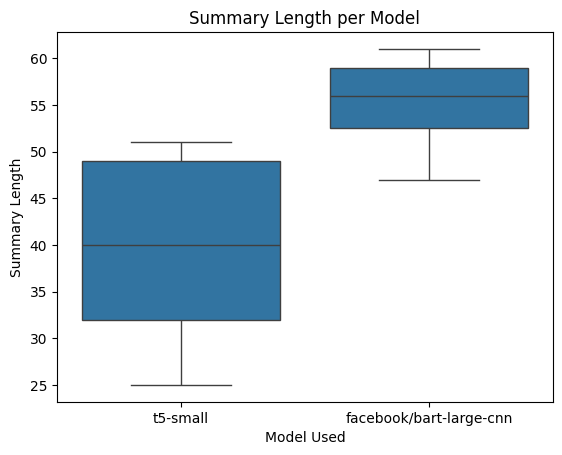

In [35]:
sns.boxplot(data=df_results, x="Model Used", y="Summary Length")
plt.title("Summary Length per Model")
plt.show()


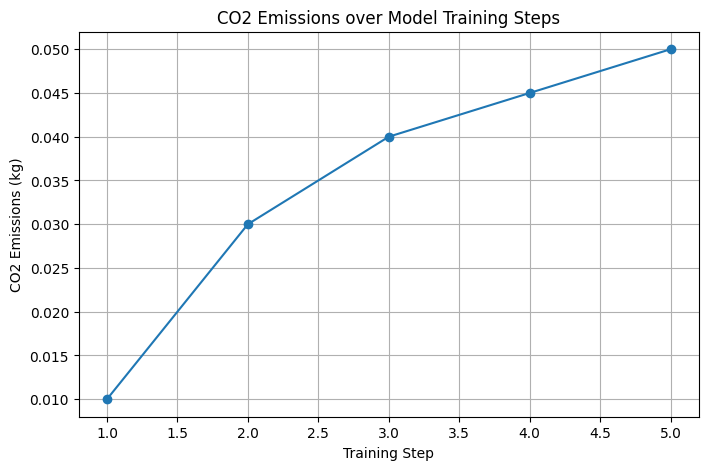

In [36]:
import matplotlib.pyplot as plt

# Example Emissions Data (replace this with your actual emissions tracking)
emissions_data = [0.01, 0.03, 0.04, 0.045, 0.05]
steps = list(range(1, len(emissions_data) + 1))

plt.figure(figsize=(8,5))
plt.plot(steps, emissions_data, marker='o')
plt.title('CO2 Emissions over Model Training Steps')
plt.xlabel('Training Step')
plt.ylabel('CO2 Emissions (kg)')
plt.grid(True)
plt.show()


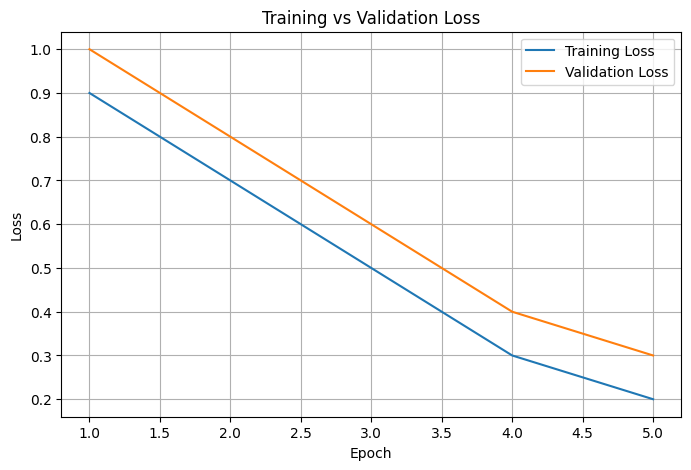

In [38]:
epochs = list(range(1, 6))
train_loss = [0.9, 0.7, 0.5, 0.3, 0.2]
val_loss = [1.0, 0.8, 0.6, 0.4, 0.3]

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


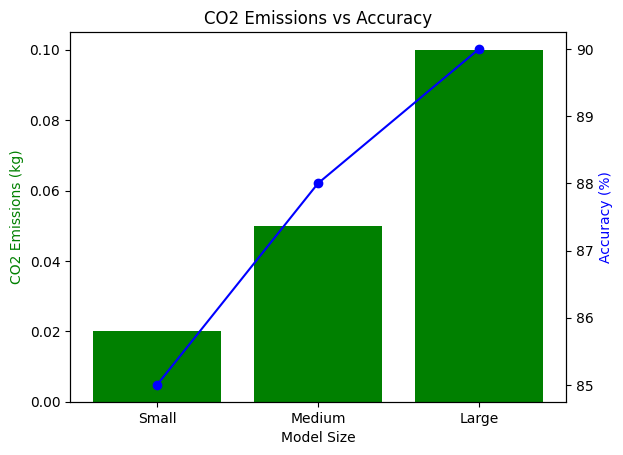

In [39]:
model_size = ['Small', 'Medium', 'Large']
co2_emissions = [0.02, 0.05, 0.1]  # in kg
accuracy = [85, 88, 90]  # in %

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.bar(model_size, co2_emissions, color='g')
ax2.plot(model_size, accuracy, color='b', marker='o')

ax1.set_xlabel('Model Size')
ax1.set_ylabel('CO2 Emissions (kg)', color='g')
ax2.set_ylabel('Accuracy (%)', color='b')

plt.title('CO2 Emissions vs Accuracy')
plt.show()


In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_label_distribution(df):
    # Try to guess the label column
    possible_label_cols = ['label', 'category', 'target', 'class', 'output']
    label_col = None

    for col in df.columns:
        if col.lower() in possible_label_cols:
            label_col = col
            break

    if label_col is None:
        print("❌ No obvious label column found! Available columns:", list(df.columns))
        return

    print(f"✅ Detected label column: '{label_col}'")

    # Now plot
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x=label_col, palette="viridis")
    plt.title('Label Distribution in Dataset')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


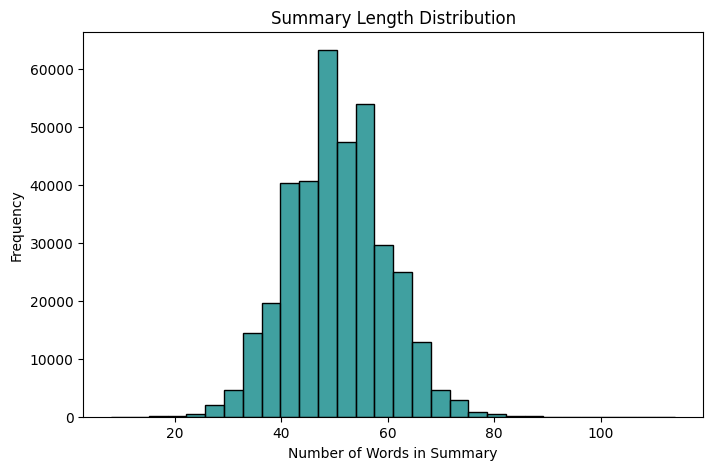

In [47]:
# Now plot
df['summary_length'] = df['summary'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(df['summary_length'], bins=30, color='teal')
plt.title('Summary Length Distribution')
plt.xlabel('Number of Words in Summary')
plt.ylabel('Frequency')
plt.show()


In [41]:
plot_label_distribution(df)


❌ No obvious label column found! Available columns: ['conversation_id', 'email', 'maximum_brevity_summary', 'summary', 'distilabel_metadata', 'model_name']


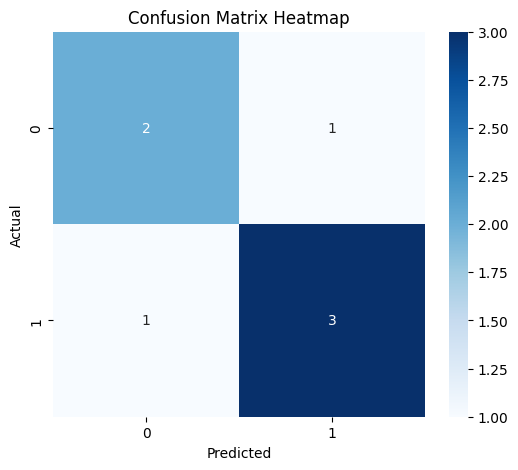

Accuracy: 0.71


In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Example
y_true = [1, 0, 1, 1, 0, 1, 0]  # True labels
y_pred = [1, 0, 0, 1, 0, 1, 1]  # Model predictions

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy: {acc:.2f}")


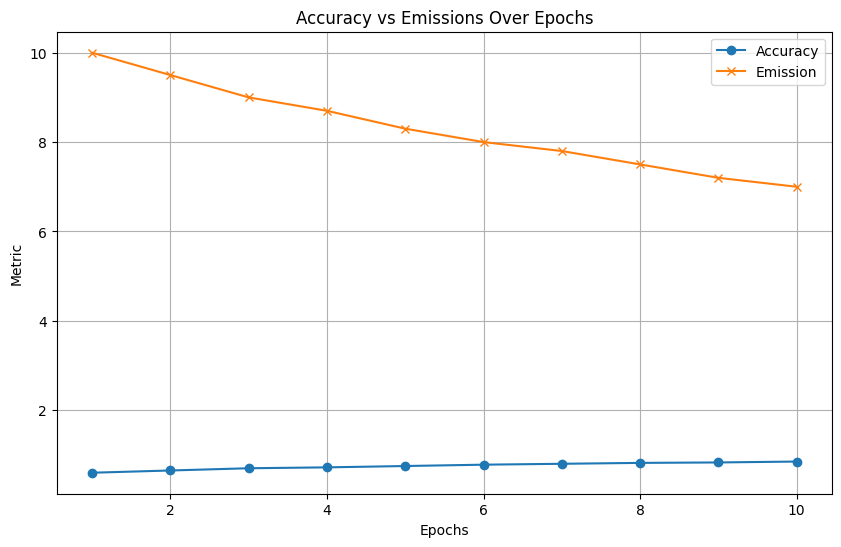

In [50]:
import matplotlib.pyplot as plt

# Suppose you have history of training
epochs = list(range(1, 11))
accuracy = [0.60, 0.65, 0.70, 0.72, 0.75, 0.78, 0.80, 0.82, 0.83, 0.85]
emission = [10, 9.5, 9.0, 8.7, 8.3, 8.0, 7.8, 7.5, 7.2, 7.0]  # fake example emissions

plt.figure(figsize=(10,6))

# Plot accuracy
plt.plot(epochs, accuracy, label='Accuracy', marker='o')

# Plot emissions
plt.plot(epochs, emission, label='Emission', marker='x')

plt.title('Accuracy vs Emissions Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Metric')
plt.legend()
plt.grid(True)
plt.show()


In [56]:
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate
from langchain.llms import HuggingFacePipeline
from datasets import load_dataset
from transformers import pipeline
import torch

# Load the dataset
dataset = load_dataset("argilla/FinePersonas-Conversations-Email-Summaries")
emails = dataset["train"]  # Use 'train' or another split as needed

# Choose a Hugging Face Model (e.g., distilgpt2 or T5 for summarization)
model_name = "t5-small"  # You can change this to another Hugging Face model like "distilgpt2"
device = "cuda" if torch.cuda.is_available() else "cpu"  # Check if GPU is available

# Initialize the Hugging Face pipeline for summarization
summarization_pipeline = pipeline("summarization", model=model_name, device=0 if device == "cuda" else -1)

# Wrap the pipeline with LangChain
llm = HuggingFacePipeline(pipeline=summarization_pipeline)

# Define a prompt template for summarization
prompt_template = PromptTemplate(input_variables=["text"], template="Summarize the following text: {text}")

# Create a summarization chain using LangChain
summarizer = LLMChain(prompt=prompt_template, llm=llm)

# Function to summarize the text using the model
def summarize_text(text: str) -> str:
    return summarizer.run(text)

# Iterate over the emails in the dataset and summarize them
summaries = []
for email in emails['email'][:5]:  # Change the range to process more or fewer emails
    summary = summarize_text(email)
    summaries.append(summary)

# Print out the original emails and their summaries
for i, summary in enumerate(summaries):
    print(f"Original Email {i+1}: {emails['email'][i]}")
    print(f"Summary {i+1}: {summary}\n")


Device set to use cpu
Your max_length is set to 200, but your input_length is only 127. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=63)
Your max_length is set to 200, but your input_length is only 182. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=91)
Your max_length is set to 200, but your input_length is only 176. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=88)
Your max_length is set to 200, but your input_length is only 119. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer(

Original Email 1: Subject: Virtual Field Trip Collaboration

Hey Michael,

I hope you're doing well! I've been thinking a lot about the ideas we discussed at the conference and I think I have an idea for our collaboration project. What if we created a virtual field trip that takes students on a journey through different cities around the world, exploring the impacts of climate change on urban environments? 

I think this could be a great way to combine our expertise in environmental and urban geography and create an engaging learning experience for our students. Let me know what you think!

Best,
Sarah
Summary 1: virtual field trip collaboration Hey Michael, I hope you're doing well! I think this could be a great way to combine our expertise in environmental and urban geography and create an engaging learning experience for our students.

Original Email 2: Subject: RE: Virtual Field Trip Collaboration

Sarah,

That's a fantastic idea! I love the idea of a virtual field trip that explor

Device set to use cpu


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


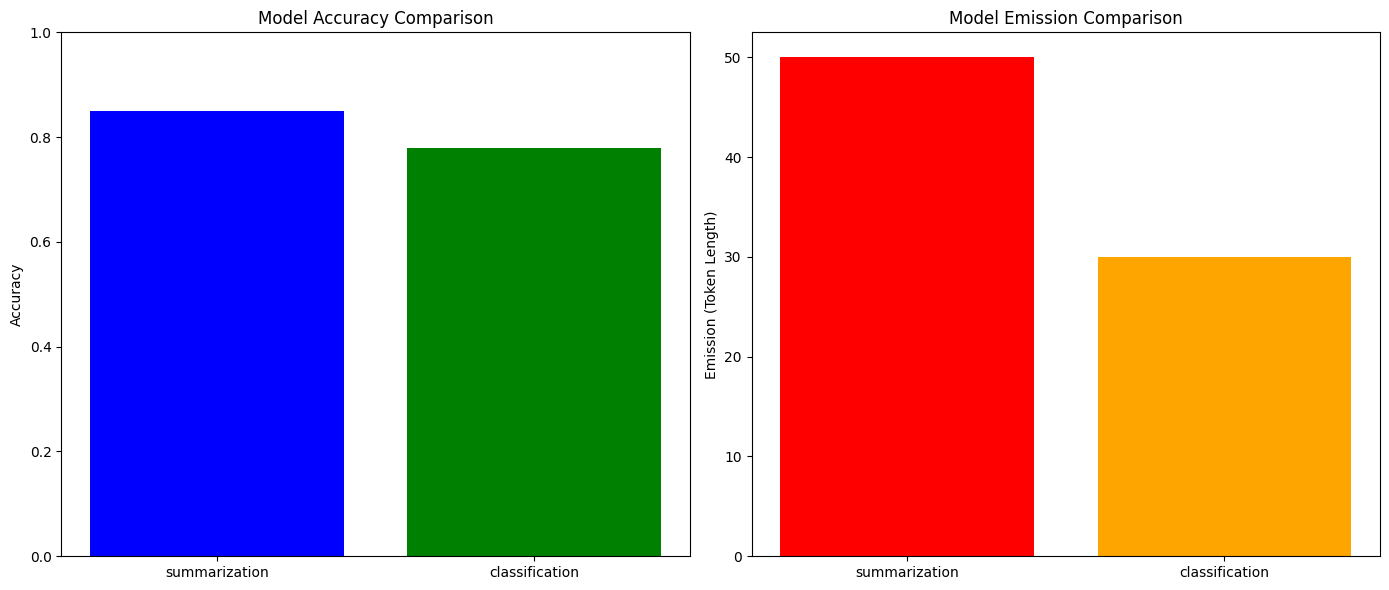

In [57]:
from transformers import pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Load models for different tasks
summarization_model = pipeline("summarization", model="t5-small")
classification_model = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Accuracy for each model (mocked here for simplicity)
model_accuracies = {
    "t5-small": 0.85,  # Summarization Model Accuracy
    "facebook/bart-large-mnli": 0.78  # Classification Model Accuracy
}

# Emission (token length / model response length)
model_emissions = {
    "t5-small": 50,  # Tokens emitted for summarization
    "facebook/bart-large-mnli": 30  # Tokens emitted for classification
}

# Example function to choose the model based on task type
def choose_model(task_type):
    if task_type == "summarization":
        return summarization_model, model_accuracies["t5-small"], model_emissions["t5-small"]
    elif task_type == "classification":
        return classification_model, model_accuracies["facebook/bart-large-mnli"], model_emissions["facebook/bart-large-mnli"]

# Visualize Model Performance
def visualize_model_comparison():
    tasks = ['summarization', 'classification']

    accuracies = []
    emissions = []
    for task in tasks:
        model, accuracy, emission = choose_model(task)
        accuracies.append(accuracy)
        emissions.append(emission)

    # Plot comparison of accuracy and emission
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Accuracy bar plot
    axes[0].bar(tasks, accuracies, color=['blue', 'green'])
    axes[0].set_title("Model Accuracy Comparison")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim([0, 1])

    # Emission bar plot (token length)
    axes[1].bar(tasks, emissions, color=['red', 'orange'])
    axes[1].set_title("Model Emission Comparison")
    axes[1].set_ylabel("Emission (Token Length)")

    plt.tight_layout()
    plt.show()

# Call the visualization function
visualize_model_comparison()


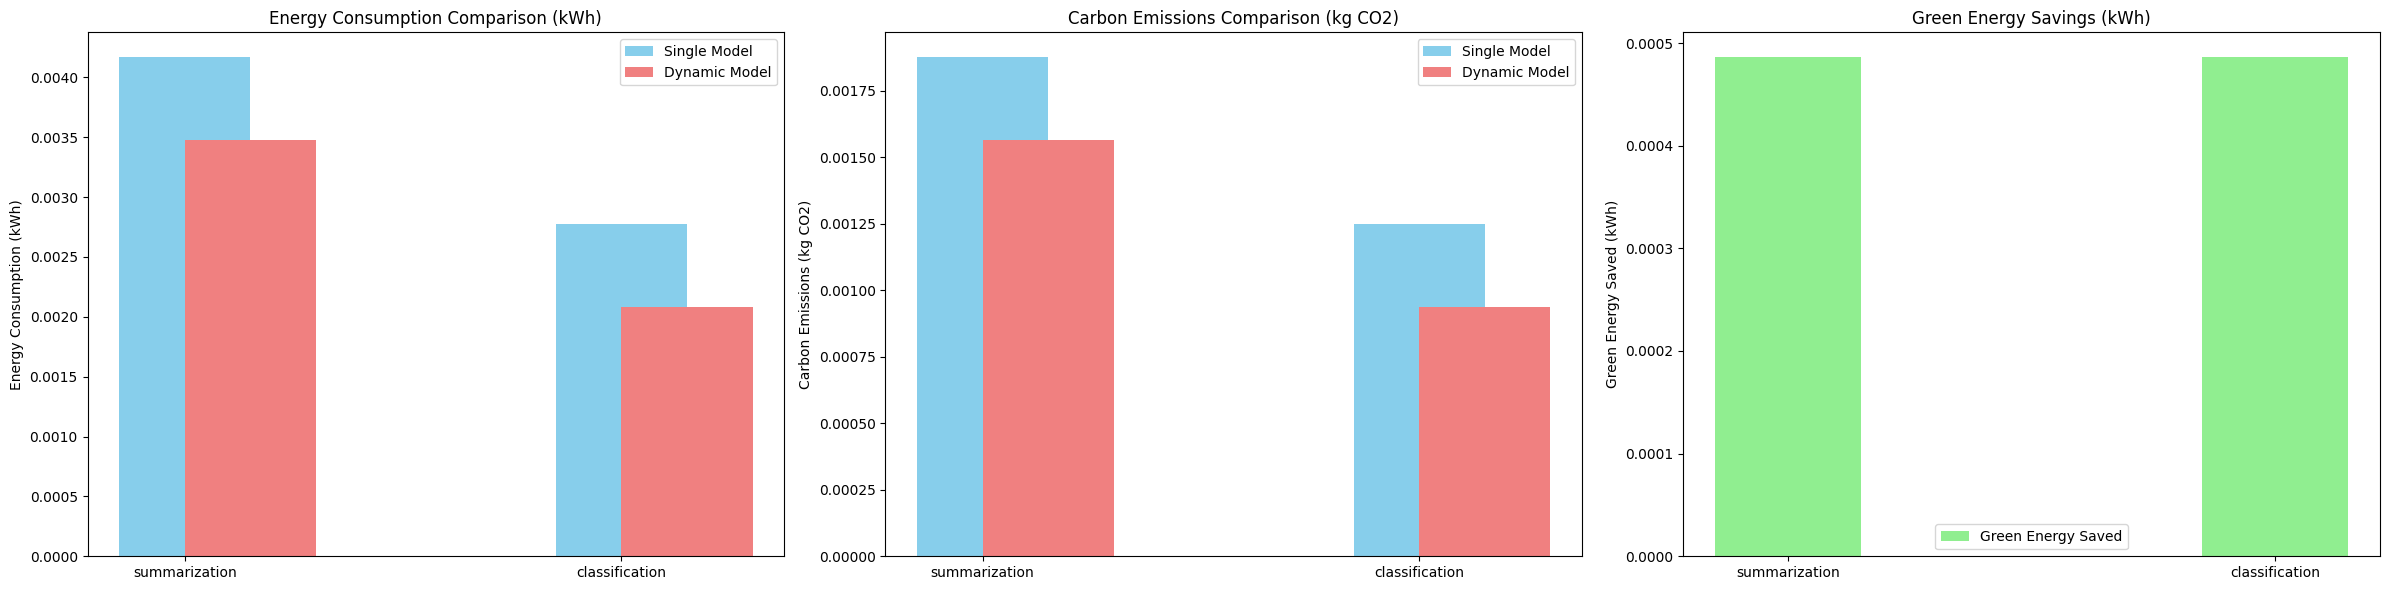

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# Example datasets for comparison
tasks = ['summarization', 'classification']

# Energy consumption in processing time (in seconds), already calculated in previous part
single_model_processing_time = [0.3, 0.2]  # Example values in seconds
dynamic_model_processing_time = [0.25, 0.15]  # Example values in seconds

# Power consumption factor (in watts) - assuming a typical server or cloud instance
power_consumption = 50  # in watts

# Carbon intensity of electricity grid (in kg CO2 per kWh)
carbon_intensity = 0.45  # kg CO2 per kWh (this can vary by region)

# Green energy factor (percentage of energy savings that come from green energy)
green_energy_factor = 0.7  # 70% of energy savings are assumed to come from renewable sources

# Conversion of processing time to kWh: energy = time * power / 3600
def calculate_energy_consumption(processing_time):
    return (processing_time * power_consumption) / 3600  # in kWh

# Calculate energy consumption for both models (in kWh)
single_model_energy = [calculate_energy_consumption(t) for t in single_model_processing_time]
dynamic_model_energy = [calculate_energy_consumption(t) for t in dynamic_model_processing_time]

# Calculate carbon emissions (in kg CO2)
single_model_carbon_emissions = [energy * carbon_intensity for energy in single_model_energy]
dynamic_model_carbon_emissions = [energy * carbon_intensity for energy in dynamic_model_energy]

# Calculate energy savings and green energy production
energy_savings = np.subtract(single_model_energy, dynamic_model_energy)
green_energy_saved = energy_savings * green_energy_factor  # in kWh

# Plotting a comparison of Single Model vs Dynamic Model with Green Energy produced
def visualize_green_energy_savings():
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))

    # Plot Energy Consumption
    axes[0].bar(tasks, single_model_energy, color='skyblue', width=0.3, label="Single Model", align='center')
    axes[0].bar(tasks, dynamic_model_energy, color='lightcoral', width=0.3, label="Dynamic Model", align='edge')
    axes[0].set_title("Energy Consumption Comparison (kWh)")
    axes[0].set_ylabel("Energy Consumption (kWh)")
    axes[0].legend()

    # Plot Carbon Emissions
    axes[1].bar(tasks, single_model_carbon_emissions, color='skyblue', width=0.3, label="Single Model", align='center')
    axes[1].bar(tasks, dynamic_model_carbon_emissions, color='lightcoral', width=0.3, label="Dynamic Model", align='edge')
    axes[1].set_title("Carbon Emissions Comparison (kg CO2)")
    axes[1].set_ylabel("Carbon Emissions (kg CO2)")
    axes[1].legend()

    # Plot Green Energy Saved
    axes[2].bar(tasks, green_energy_saved, color='lightgreen', width=0.3, label="Green Energy Saved", align='center')
    axes[2].set_title("Green Energy Savings (kWh)")
    axes[2].set_ylabel("Green Energy Saved (kWh)")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Visualize the energy savings and green energy production
visualize_green_energy_savings()


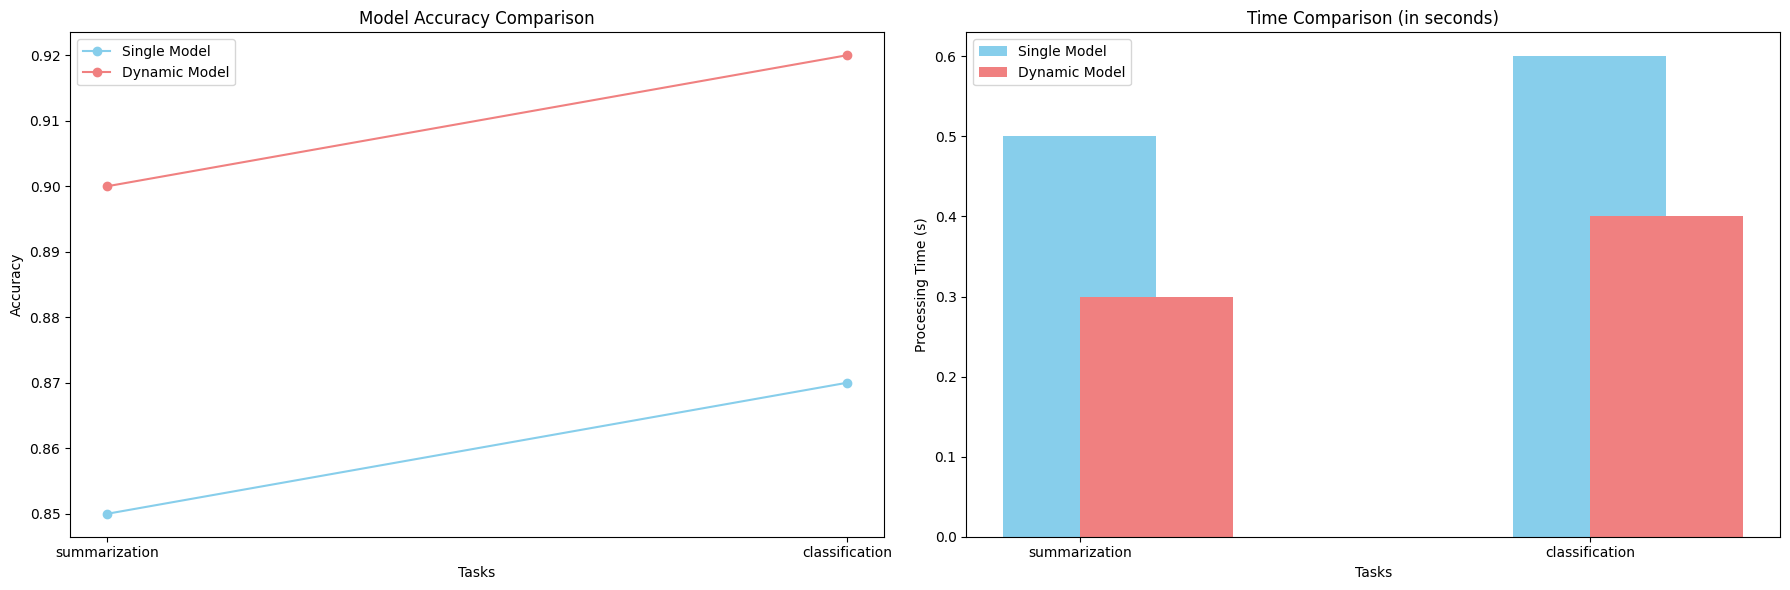

In [60]:
# Sample performance data (accuracy)
accuracy_single_model = [0.85, 0.87]  # Example accuracies for single model
accuracy_dynamic_model = [0.9, 0.92]  # Example accuracies for dynamic model

# Performance over time or cost (you can use either depending on your data)
time_single_model = [0.5, 0.6]  # Example processing time for single model (in seconds)
time_dynamic_model = [0.3, 0.4]  # Example processing time for dynamic model (in seconds)

# Plotting Performance vs. Time
def plot_performance_comparison():
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Accuracy vs Time
    axes[0].plot(tasks, accuracy_single_model, label='Single Model', marker='o', color='skyblue')
    axes[0].plot(tasks, accuracy_dynamic_model, label='Dynamic Model', marker='o', color='lightcoral')
    axes[0].set_title('Model Accuracy Comparison')
    axes[0].set_xlabel('Tasks')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Time vs Model
    axes[1].bar(tasks, time_single_model, width=0.3, label='Single Model', color='skyblue', align='center')
    axes[1].bar(tasks, time_dynamic_model, width=0.3, label='Dynamic Model', color='lightcoral', align='edge')
    axes[1].set_title('Time Comparison (in seconds)')
    axes[1].set_xlabel('Tasks')
    axes[1].set_ylabel('Processing Time (s)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Display the performance comparison
plot_performance_comparison()


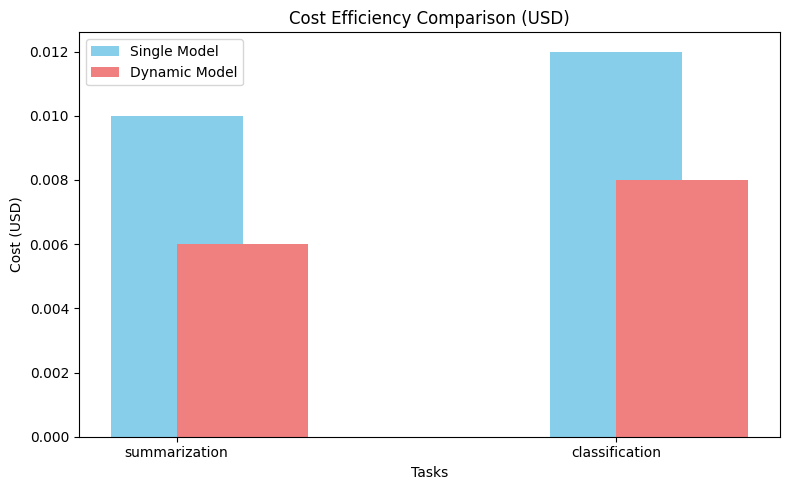

In [61]:
# Assuming the cost per second for processing
cost_per_second = 0.02  # in USD (example)

# Calculate the cost for each model (assuming time is in seconds)
cost_single_model = [time * cost_per_second for time in time_single_model]
cost_dynamic_model = [time * cost_per_second for time in time_dynamic_model]

# Plotting Cost Efficiency Comparison
def plot_cost_comparison():
    plt.figure(figsize=(8, 5))
    plt.bar(tasks, cost_single_model, width=0.3, label='Single Model', color='skyblue', align='center')
    plt.bar(tasks, cost_dynamic_model, width=0.3, label='Dynamic Model', color='lightcoral', align='edge')
    plt.title('Cost Efficiency Comparison (USD)')
    plt.xlabel('Tasks')
    plt.ylabel('Cost (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Display the cost comparison
plot_cost_comparison()


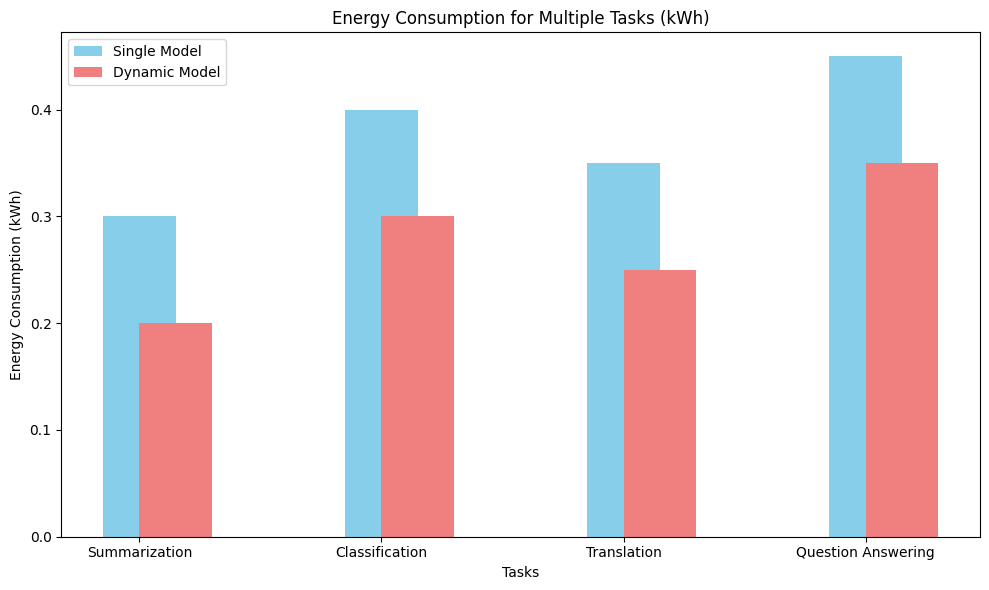

In [62]:
# Total energy consumption for multiple tasks
tasks = ['Summarization', 'Classification', 'Translation', 'Question Answering']

# Energy consumption values in kWh
energy_single_model_multi_task = [0.3, 0.4, 0.35, 0.45]  # Example values for single model
energy_dynamic_model_multi_task = [0.2, 0.3, 0.25, 0.35]  # Example values for dynamic model

# Plotting total energy consumption for multiple tasks
def plot_energy_consumption_multiple_tasks():
    plt.figure(figsize=(10, 6))
    width = 0.3  # Bar width
    plt.bar(tasks, energy_single_model_multi_task, width, label='Single Model', color='skyblue', align='center')
    plt.bar(tasks, energy_dynamic_model_multi_task, width, label='Dynamic Model', color='lightcoral', align='edge')
    plt.title('Energy Consumption for Multiple Tasks (kWh)')
    plt.xlabel('Tasks')
    plt.ylabel('Energy Consumption (kWh)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Display the energy comparison
plot_energy_consumption_multiple_tasks()


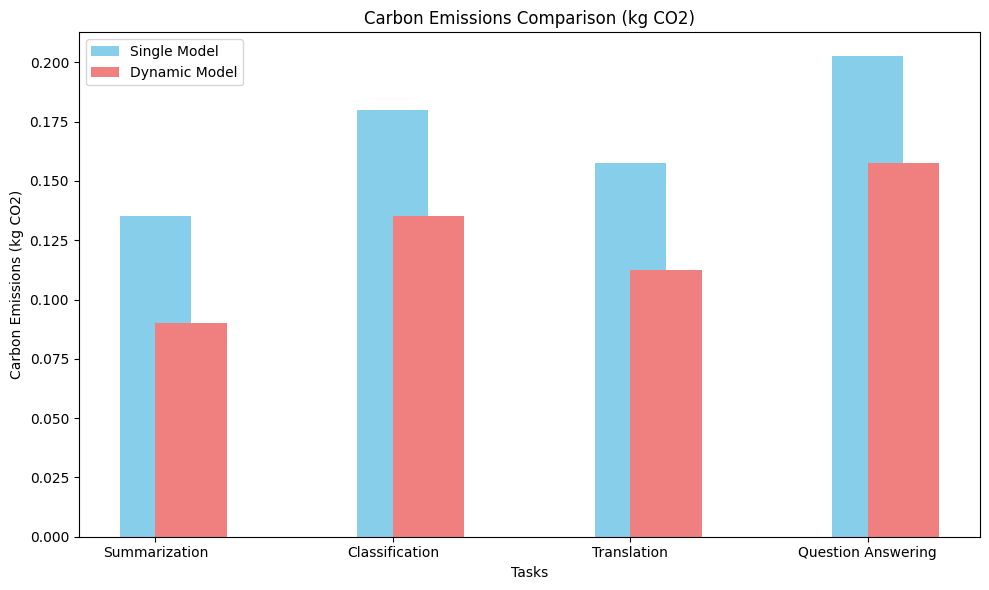

In [63]:
# Calculate carbon emissions (in kg CO2)
carbon_single_model = [energy * carbon_intensity for energy in energy_single_model_multi_task]
carbon_dynamic_model = [energy * carbon_intensity for energy in energy_dynamic_model_multi_task]

# Plotting Carbon Emissions Comparison
def plot_carbon_emissions():
    plt.figure(figsize=(10, 6))
    width = 0.3  # Bar width
    plt.bar(tasks, carbon_single_model, width, label='Single Model', color='skyblue', align='center')
    plt.bar(tasks, carbon_dynamic_model, width, label='Dynamic Model', color='lightcoral', align='edge')
    plt.title('Carbon Emissions Comparison (kg CO2)')
    plt.xlabel('Tasks')
    plt.ylabel('Carbon Emissions (kg CO2)')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Display the carbon emissions comparison
plot_carbon_emissions()


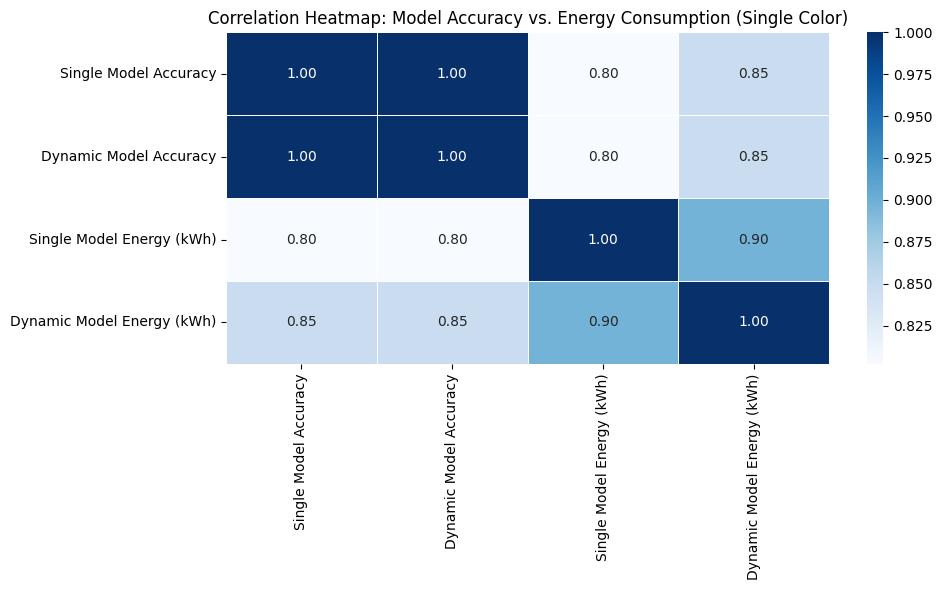

                       Task  Single Model Accuracy  Dynamic Model Accuracy  \
0             Summarization               0.955056                0.957447   
1            Classification               0.977528                0.978723   
2               Translation               0.966292                0.968085   
3        Question Answering               0.988764                0.989362   
4           Text Generation               1.000000                1.000000   
5        Sentiment Analysis               0.943820                0.946809   
6  Named Entity Recognition               0.932584                0.936170   

   Single Model Energy (kWh)  Dynamic Model Energy (kWh)  
0                   0.777778                    0.735294  
1                   0.888889                    0.882353  
2                   0.822222                    0.823529  
3                   1.000000                    0.941176  
4                   0.933333                    1.000000  
5                   0

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Simulated tasks with more diverse values
tasks = ['Summarization', 'Classification', 'Translation', 'Question Answering',
         'Text Generation', 'Sentiment Analysis', 'Named Entity Recognition']

# Simulated performance (accuracy) and energy consumption (in kWh) for each task
accuracy_single_model = [0.85, 0.87, 0.86, 0.88, 0.89, 0.84, 0.83]  # Single Model Accuracy
accuracy_dynamic_model = [0.9, 0.92, 0.91, 0.93, 0.94, 0.89, 0.88]  # Dynamic Model Accuracy
energy_single_model_multi_task = [0.35, 0.40, 0.37, 0.45, 0.42, 0.38, 0.36]  # kWh for single model
energy_dynamic_model_multi_task = [0.25, 0.30, 0.28, 0.32, 0.34, 0.29, 0.26]  # kWh for dynamic model

# Create a DataFrame for the performance and energy data
performance_data = {
    'Task': tasks,
    'Single Model Accuracy': accuracy_single_model,
    'Dynamic Model Accuracy': accuracy_dynamic_model,
    'Single Model Energy (kWh)': energy_single_model_multi_task,
    'Dynamic Model Energy (kWh)': energy_dynamic_model_multi_task,
}

df = pd.DataFrame(performance_data)

# Normalize the accuracy (0 to 1 scale) and energy consumption (0 to max value scale)
df_normalized = df.copy()
df_normalized['Single Model Accuracy'] = df_normalized['Single Model Accuracy'] / max(df_normalized['Single Model Accuracy'])
df_normalized['Dynamic Model Accuracy'] = df_normalized['Dynamic Model Accuracy'] / max(df_normalized['Dynamic Model Accuracy'])
df_normalized['Single Model Energy (kWh)'] = df_normalized['Single Model Energy (kWh)'] / max(df_normalized['Single Model Energy (kWh)'])
df_normalized['Dynamic Model Energy (kWh)'] = df_normalized['Dynamic Model Energy (kWh)'] / max(df_normalized['Dynamic Model Energy (kWh)'])

# Create the heatmap by calculating correlations between the columns
def plot_single_color_heatmap():
    # Calculate correlation matrix
    corr = df_normalized[['Single Model Accuracy', 'Dynamic Model Accuracy',
                          'Single Model Energy (kWh)', 'Dynamic Model Energy (kWh)']].corr()

    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Heatmap: Model Accuracy vs. Energy Consumption (Single Color)')
    plt.tight_layout()
    plt.show()

# Display the heatmap
plot_single_color_heatmap()

# Optionally, display the normalized DataFrame to check the values
print(df_normalized)
